<a href="https://colab.research.google.com/github/neilvzx/predictive-maintenance-ml/blob/main/EMPLOYEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Employee.csv to Employee.csv


In [2]:
import pandas as pd

df = pd.read_csv('Employee.csv')
print(df.shape)
df.head()

(4653, 9)


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [3]:
print(df.dtypes)
print(df.isnull().sum())
df.describe(include='all')

Education                    object
JoiningYear                   int64
City                         object
PaymentTier                   int64
Age                           int64
Gender                       object
EverBenched                  object
ExperienceInCurrentDomain     int64
LeaveOrNot                    int64
dtype: object
Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
count,4653,4653.000000,4653,4653.000000,4653.000000,4653,4653,4653.000000,4653.000000
unique,3,NaN,3,NaN,NaN,2,2,NaN,NaN
top,Bachelors,NaN,Bangalore,NaN,NaN,Male,No,NaN,NaN
freq,3601,NaN,2228,NaN,NaN,2778,4175,NaN,NaN
mean,NaN,2015.062970,NaN,2.698259,29.393295,NaN,NaN,2.905652,0.343864
std,NaN,1.863377,NaN,0.561435,4.826087,NaN,NaN,1.558240,0.475047
min,NaN,2012.000000,NaN,1.000000,22.000000,NaN,NaN,0.000000,0.000000
25%,NaN,2013.000000,NaN,3.000000,26.000000,NaN,NaN,2.000000,0.000000
50%,NaN,2015.000000,NaN,3.000000,28.000000,NaN,NaN,3.000000,0.000000
75%,NaN,2017.000000,NaN,3.000000,32.000000,NaN,NaN,4.000000,1.000000


In [4]:
print(df['Education'].value_counts())
print(df['Education'].value_counts(normalize=True).round(3) * 100)

Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64
Education
Bachelors    77.4
Masters      18.8
PHD           3.8
Name: proportion, dtype: float64


In [5]:
print(df['City'].value_counts())
print(df.groupby('City')['JoiningYear'].agg(['mean', 'median', 'min', 'max', 'count']))

City
Bangalore    2228
Pune         1268
New Delhi    1157
Name: count, dtype: int64
                  mean  median   min   max  count
City                                             
Bangalore  2014.859515  2015.0  2012  2018   2228
New Delhi  2015.522040  2016.0  2012  2018   1157
Pune       2015.001577  2015.0  2012  2018   1268


In [6]:
print(df['PaymentTier'].value_counts().sort_index())
print(df[['PaymentTier', 'ExperienceInCurrentDomain']].corr())
print(df.groupby('PaymentTier')['ExperienceInCurrentDomain'].mean())

PaymentTier
1     243
2     918
3    3492
Name: count, dtype: int64
                           PaymentTier  ExperienceInCurrentDomain
PaymentTier                   1.000000                   0.018314
ExperienceInCurrentDomain     0.018314                   1.000000
PaymentTier
1    2.761317
2    2.900871
3    2.916953
Name: ExperienceInCurrentDomain, dtype: float64


In [7]:
print(df['Gender'].value_counts())
print(df['Gender'].value_counts(normalize=True).round(3) * 100)

Gender
Male      2778
Female    1875
Name: count, dtype: int64
Gender
Male      59.7
Female    40.3
Name: proportion, dtype: float64


In [8]:
print(df['LeaveOrNot'].value_counts(normalize=True).round(3) * 100)
print(df.groupby('Gender')['LeaveOrNot'].mean().round(3))
print(df.groupby('Education')['LeaveOrNot'].mean().round(3))
print(df.groupby('City')['LeaveOrNot'].mean().round(3))
print(df.groupby('PaymentTier')['LeaveOrNot'].mean().round(3))
print(df.groupby('EverBenched')['LeaveOrNot'].mean().round(3))
print(df.groupby('JoiningYear')['LeaveOrNot'].mean().round(3))

LeaveOrNot
0    65.6
1    34.4
Name: proportion, dtype: float64
Gender
Female    0.471
Male      0.258
Name: LeaveOrNot, dtype: float64
Education
Bachelors    0.314
Masters      0.488
PHD          0.251
Name: LeaveOrNot, dtype: float64
City
Bangalore    0.267
New Delhi    0.316
Pune         0.504
Name: LeaveOrNot, dtype: float64
PaymentTier
1    0.366
2    0.599
3    0.275
Name: LeaveOrNot, dtype: float64
EverBenched
No     0.331
Yes    0.454
Name: LeaveOrNot, dtype: float64
JoiningYear
2012    0.216
2013    0.335
2014    0.247
2015    0.407
2016    0.223
2017    0.268
2018    0.986
Name: LeaveOrNot, dtype: float64


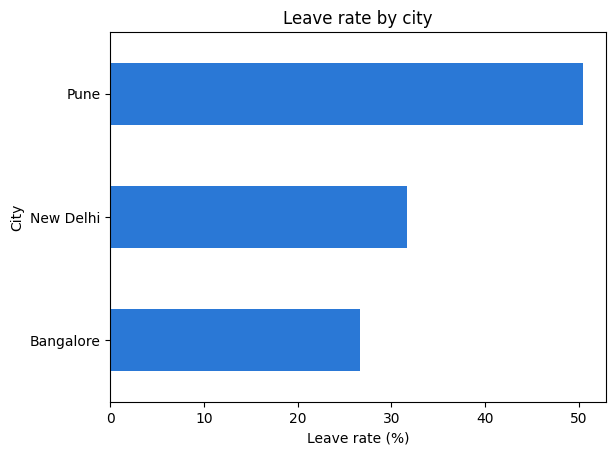

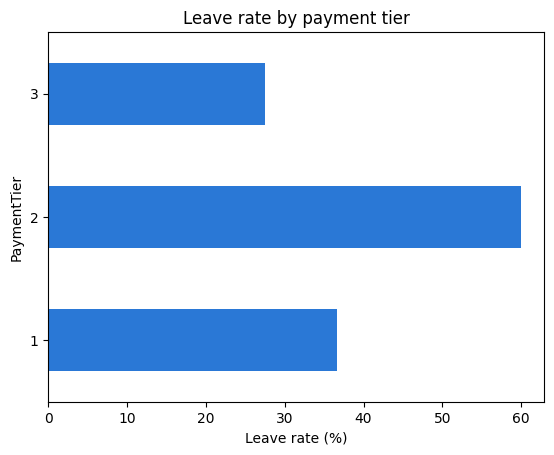

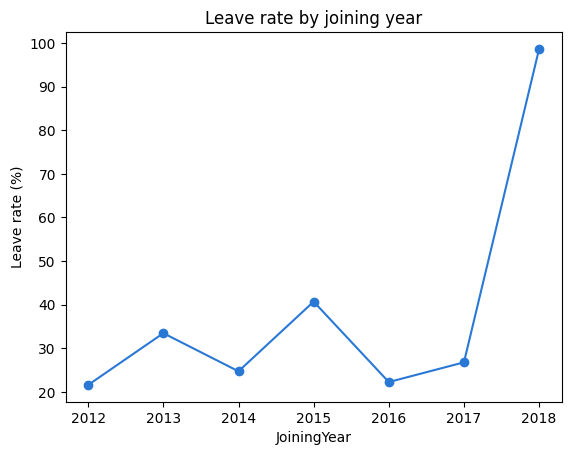

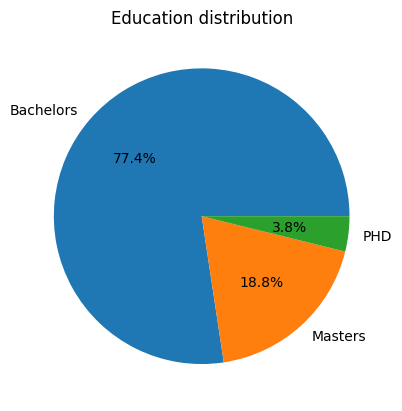

In [9]:
import matplotlib.pyplot as plt

# Leave rate by city
df.groupby('City')['LeaveOrNot'].mean().mul(100).plot(kind='barh', color='#2a78d6')
plt.xlabel('Leave rate (%)')
plt.title('Leave rate by city')
plt.show()

# Leave rate by payment tier
df.groupby('PaymentTier')['LeaveOrNot'].mean().mul(100).plot(kind='barh', color='#2a78d6')
plt.xlabel('Leave rate (%)')
plt.title('Leave rate by payment tier')
plt.show()

# Leave rate by joining year
df.groupby('JoiningYear')['LeaveOrNot'].mean().mul(100).plot(kind='line', marker='o', color='#2a78d6')
plt.ylabel('Leave rate (%)')
plt.title('Leave rate by joining year')
plt.show()

# Education distribution pie chart
df['Education'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Education distribution')
plt.show()